<a href="https://colab.research.google.com/github/raeinard/Restaurant-Sales-Analysis-SQL-Based-/blob/main/Restaurant_Analysis_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import sqlite3

# 1. Load built-in data
df = sns.load_dataset('tips')

# 2. Connect to a local SQL database file
conn = sqlite3.connect('restaurant.db')

# 3. Save the data into a table named 'orders'
df.to_sql('orders', conn, if_exists='replace', index=False)

print("SQL Database 'restaurant.db' created with table 'orders'!")
df.head()


SQL Database 'restaurant.db' created with table 'orders'!


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# SQL Query: Sum of total_bill grouped by day
query = """
SELECT
    day,
    SUM(total_bill) as daily_revenue,
    AVG(tip) as average_tip
FROM orders
GROUP BY day
ORDER BY daily_revenue DESC
"""

# Fetch the result
revenue_report = pd.read_sql_query(query, conn)
revenue_report


,day,daily_revenue,average_tip
0,Sat,1778.40,2.993103
1,Sun,1627.16,3.255132
2,Thur,1096.33,2.771452
3,Fri,325.88,2.734737


The above helps us find which day of the week brings in the most revenue.

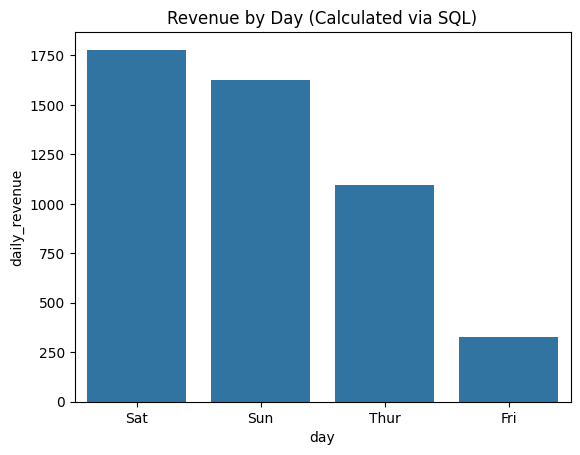

In [5]:
import matplotlib.pyplot as plt

# Create a bar chart from the result
sns.barplot(x='day', y='daily_revenue', data=revenue_report)
plt.title('Revenue by Day (Calculated via SQL)')
plt.show()


Key take aways:

Everyone is needed on the floor on Weekends to ensure Good customer experience.
Seems customers try to avoid the weekend rush by coming in on Thursday, then they create a pre-weekend rush.